In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [4]:
train = pd.read_csv("D:/Auto Hitter/py/train.csv")
test = pd.read_csv("D:/Auto Hitter/py/test.csv")

In [5]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [7]:
train.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0
749999,749999,42,technician,married,secondary,no,1559,no,no,cellular,4,aug,143,1,1,7,failure,0


In [8]:
train.shape

(750000, 18)

In [9]:
train.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [11]:
train.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

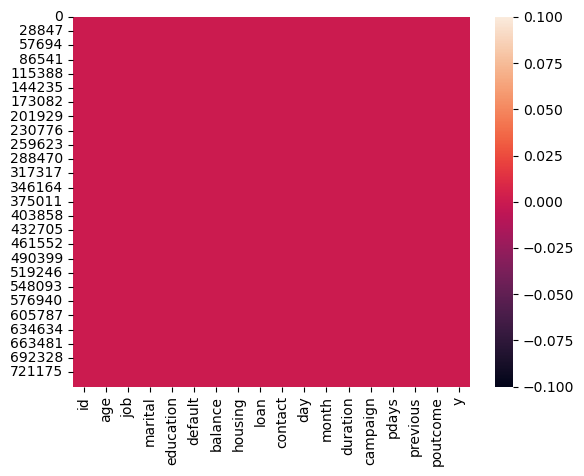

In [12]:
sns.heatmap(train.isnull())

plt.show()

In [13]:
train.duplicated().sum()

np.int64(0)

In [15]:
train=train.drop_duplicates()

In [16]:
train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [17]:
print(train.columns.tolist())

['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [18]:
train.columns = train.columns.str.strip()
print(train.columns.tolist())

['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [19]:
train["y"].value_counts()


y
0    659512
1     90488
Name: count, dtype: int64

In [20]:
train["y"].value_counts()

y
0    659512
1     90488
Name: count, dtype: int64

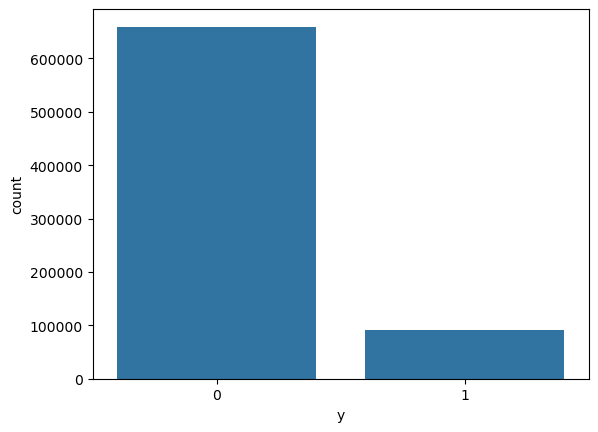

In [21]:
sns.countplot(
    data=train,
    x="y"
)

plt.show()

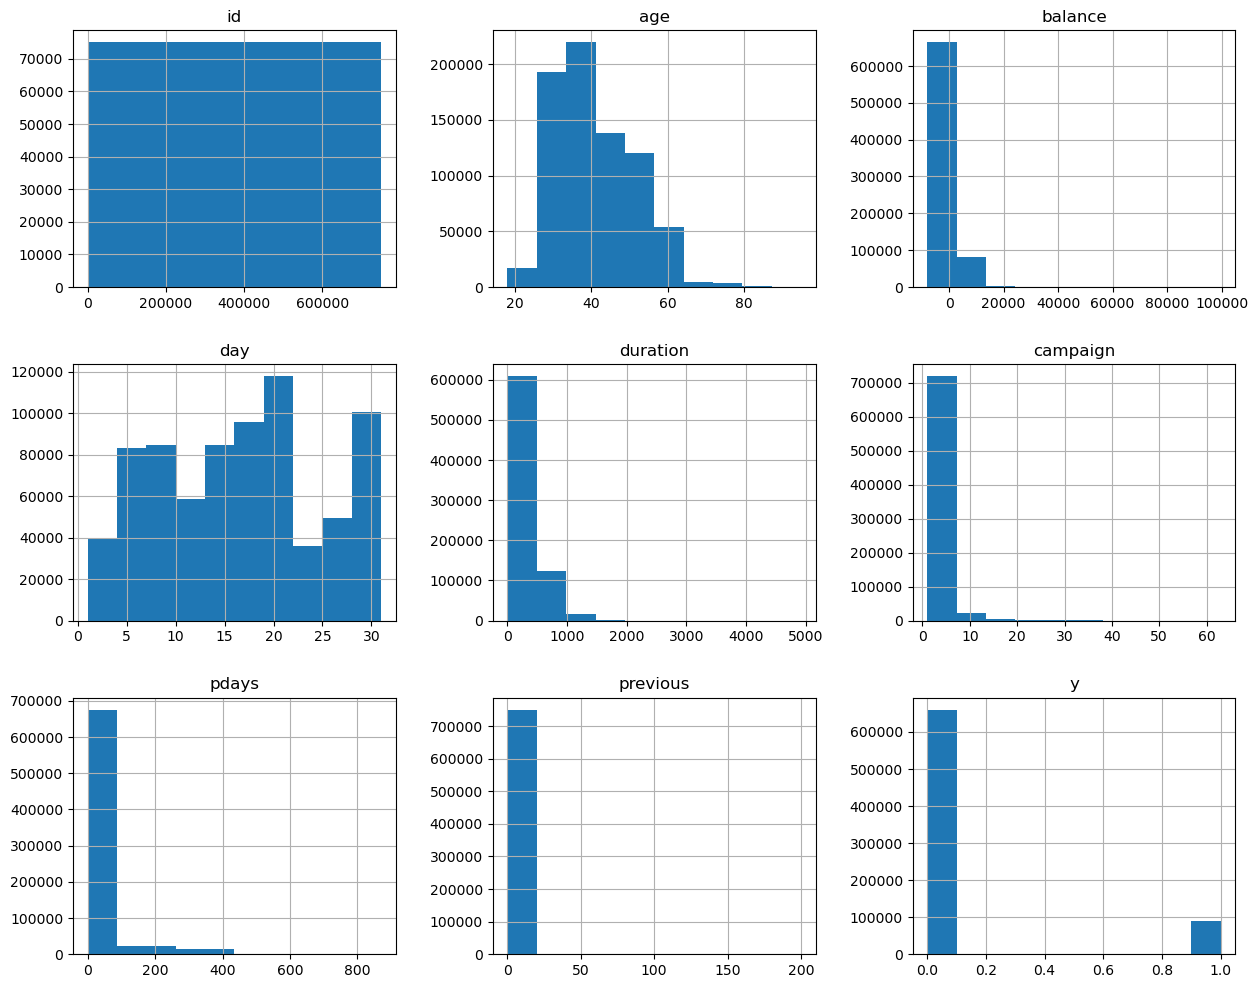

In [22]:
train.hist(
    figsize=(15,12)
)

plt.show()

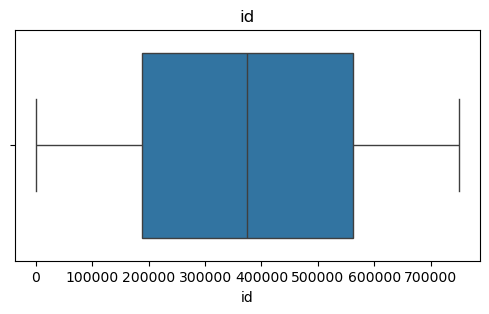

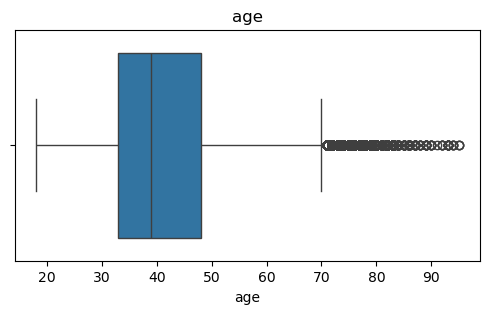

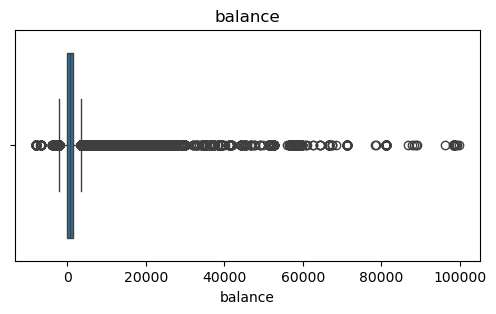

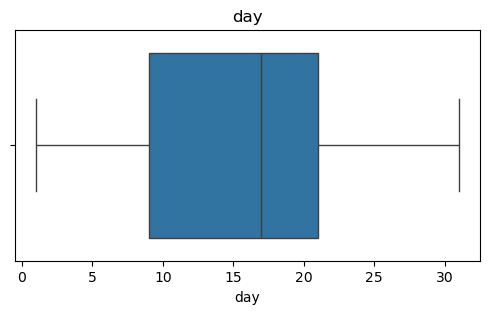

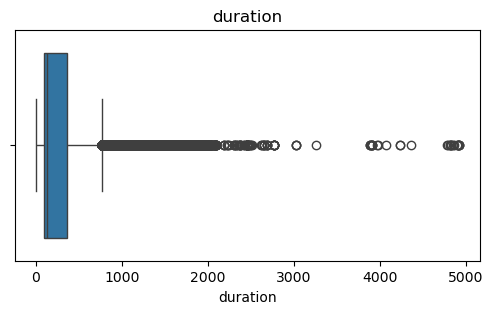

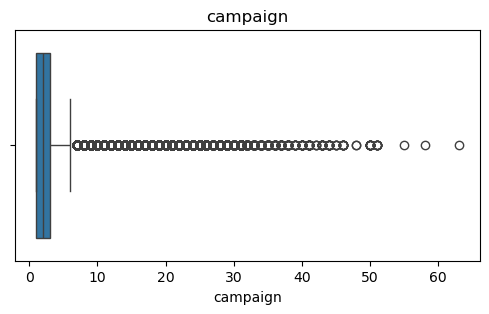

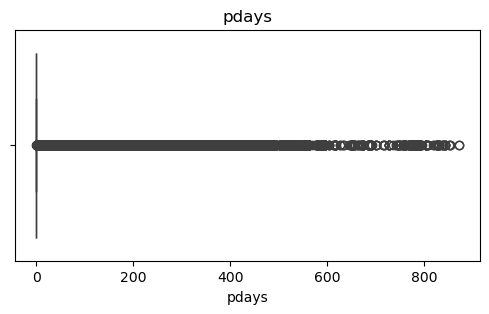

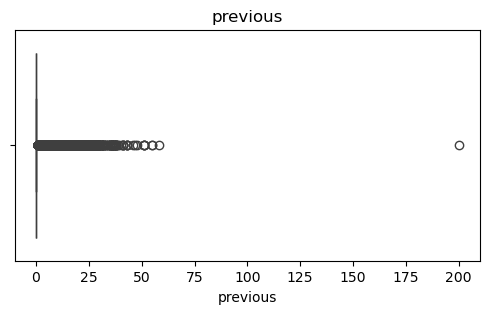

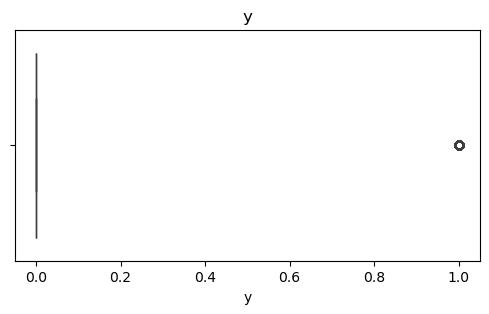

In [23]:
num=train.select_dtypes(include="number").columns

for col in num:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=train[col]
    )

    plt.title(col)

    plt.show()

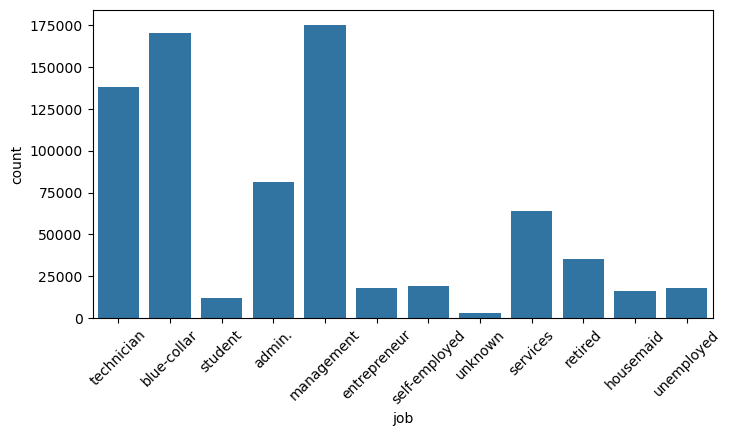

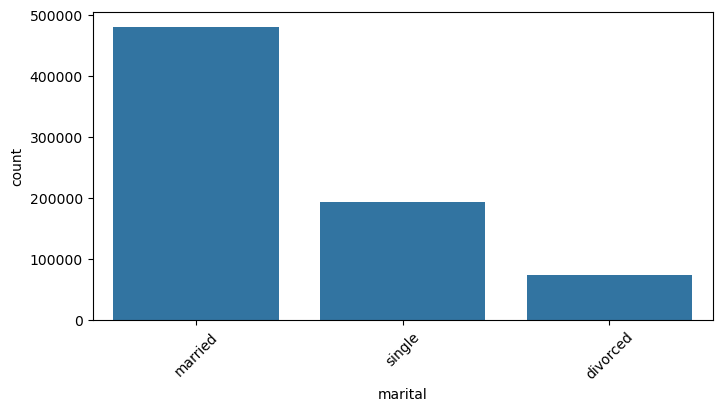

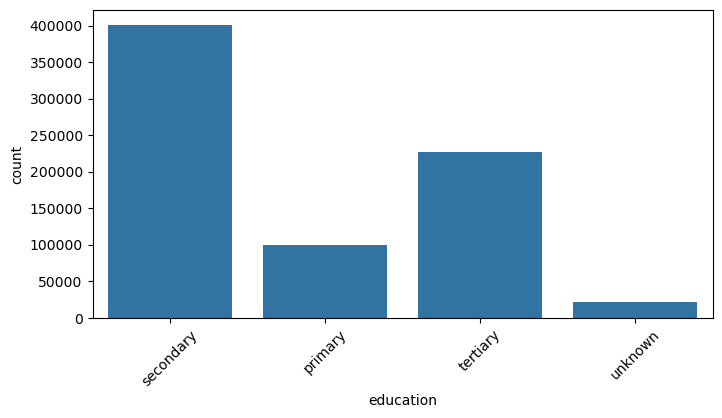

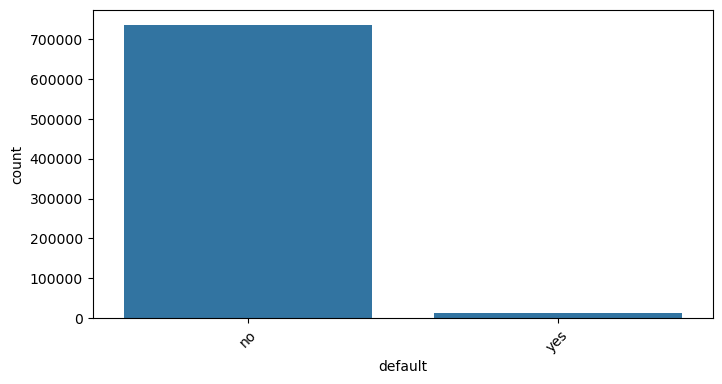

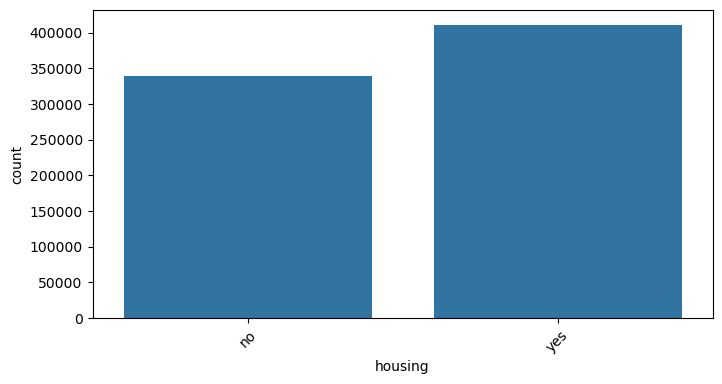

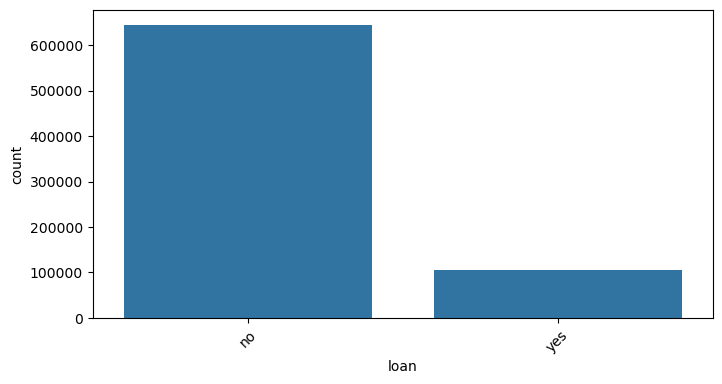

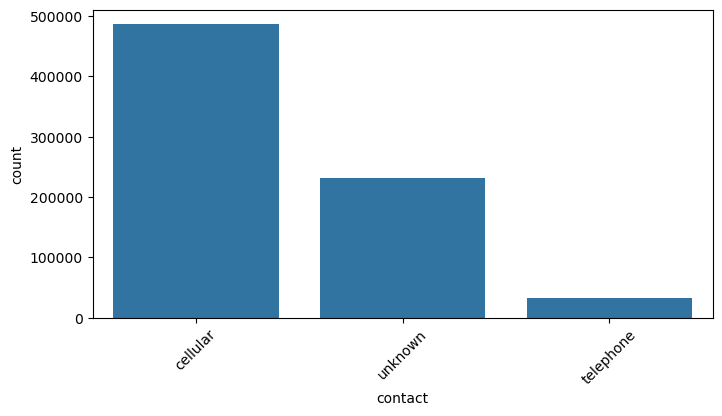

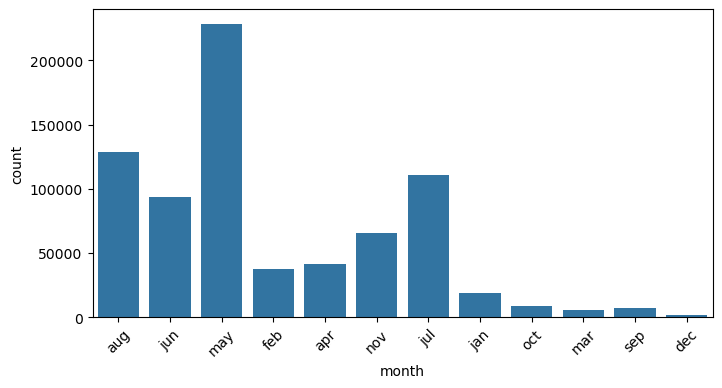

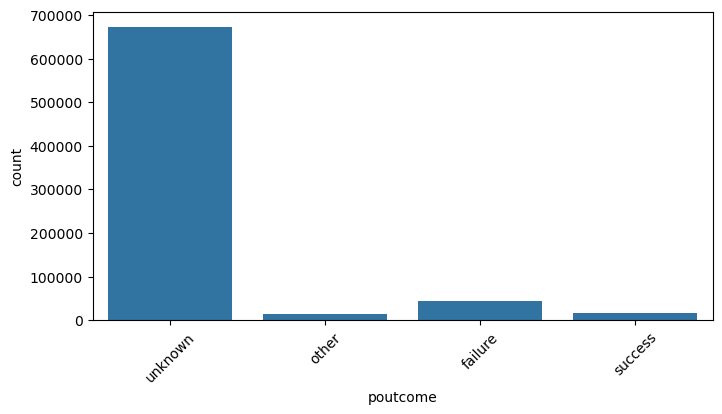

In [24]:
cat=train.select_dtypes(include="object").columns

for col in cat:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=train,
        x=col
    )

    plt.xticks(rotation=45)

    plt.show()

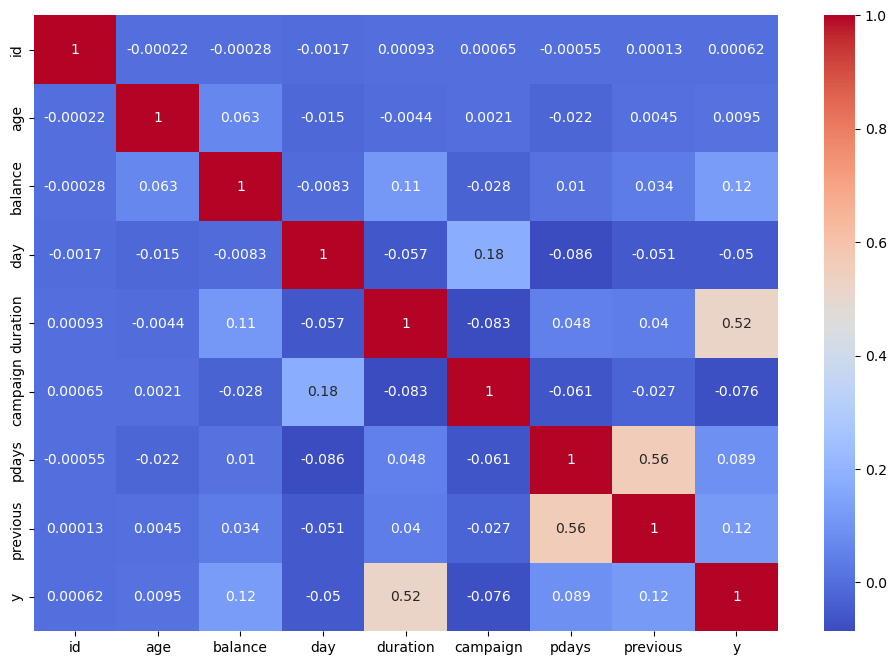

In [25]:
corr=train.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.show()

In [26]:
train["balance_per_campaign"]=train["balance"]/(train["campaign"]+1)

test["balance_per_campaign"]=test["balance"]/(test["campaign"]+1)

In [27]:
X=train.drop(
    ["id","y"],
    axis=1
)

y=train["y"]

X_test=test.drop(
    ["id"],
    axis=1
)

In [28]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

y=le.fit_transform(y)

In [29]:
X=pd.get_dummies(
    X,
    drop_first=True
)

X_test=pd.get_dummies(
    X_test,
    drop_first=True
)

X,X_test=X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [30]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

X_test=scaler.transform(X_test)

In [31]:
X_train,X_valid,y_train,y_valid=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
model=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [33]:
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [34]:
pred=model.predict(X_valid)

prob=model.predict_proba(X_valid)[:,1]

In [35]:
print(confusion_matrix(y_valid,pred))

print(classification_report(y_valid,pred))

print("ROC-AUC:", roc_auc_score(y_valid,prob))


[[128046   3856]
 [  6457  11641]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    131902
           1       0.75      0.64      0.69     18098

    accuracy                           0.93    150000
   macro avg       0.85      0.81      0.83    150000
weighted avg       0.93      0.93      0.93    150000

ROC-AUC: 0.9626160008428685


In [36]:
model.fit(
    X,
    y
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [37]:
predictions=model.predict_proba(X_test)[:,1]

In [38]:
submission=pd.DataFrame({
    "id":test["id"],
    "y":predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully")

submission.csv created successfully


In [39]:
from pathlib import Path
import joblib
import sklearn

# Recreate the feature-column information before scaling
raw_features = train.drop(
    columns=["id", "y"]
).copy()

# Exact one-hot encoded feature order used by the model
encoded_features = pd.get_dummies(
    raw_features,
    drop_first=True
)

feature_columns = encoded_features.columns.tolist()

# Store categorical column names and their training categories
categorical_columns = raw_features.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_levels = {
    column: sorted(
        raw_features[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for column in categorical_columns
}

# Store everything required for future predictions
model_bundle = {
    "model": model,
    "scaler": scaler,
    "label_encoder": le,
    "feature_columns": feature_columns,
    "raw_feature_columns": raw_features.columns.tolist(),
    "categorical_columns": categorical_columns,
    "categorical_levels": categorical_levels,
    "target_column": "y",
    "id_column": "id",
    "model_name": "RandomForestClassifier",
    "sklearn_version": sklearn.__version__
}

MODEL_PATH = Path("bank_marketing_random_forest.pkl")

joblib.dump(
    model_bundle,
    MODEL_PATH
)

print("Model saved successfully.")
print("File name:", MODEL_PATH.name)
print("Location:", MODEL_PATH.resolve())
print("Number of model features:", len(feature_columns))

Model saved successfully.
File name: bank_marketing_random_forest.pkl
Location: C:\Users\Yahya\bank_marketing_random_forest.pkl
Number of model features: 43


In [40]:
# Load the saved model bundle
loaded_bundle = joblib.load(
    "bank_marketing_random_forest.pkl"
)

# Check saved components
required_items = [
    "model",
    "scaler",
    "label_encoder",
    "feature_columns",
    "raw_feature_columns",
    "categorical_levels"
]

for item in required_items:
    assert item in loaded_bundle, f"Missing component: {item}"

# Confirm feature counts
saved_model = loaded_bundle["model"]
saved_features = loaded_bundle["feature_columns"]

assert saved_model.n_features_in_ == len(saved_features)

print("PKL file loaded and verified successfully.")
print("Model:", type(saved_model).__name__)
print("Expected features:", saved_model.n_features_in_)
print("Target classes:", loaded_bundle["label_encoder"].classes_)

PKL file loaded and verified successfully.
Model: RandomForestClassifier
Expected features: 43
Target classes: [0 1]


In [41]:
import pandas as pd
import joblib


def predict_with_saved_model(
    new_data,
    model_path="bank_marketing_random_forest.pkl"
):
    """
    Make predictions from raw bank marketing data.

    Parameters
    ----------
    new_data : pandas.DataFrame
        Raw data containing the same columns as the original test dataset.

    model_path : str
        Path to the saved model bundle.

    Returns
    -------
    pandas.DataFrame
        Predicted class and probability of y = 1.
    """

    bundle = joblib.load(model_path)

    saved_model = bundle["model"]
    saved_scaler = bundle["scaler"]
    saved_encoder = bundle["label_encoder"]
    feature_columns = bundle["feature_columns"]
    raw_feature_columns = bundle["raw_feature_columns"]
    categorical_levels = bundle["categorical_levels"]

    data = new_data.copy()

    # Preserve IDs for the final result
    if "id" in data.columns:
        record_ids = data["id"].copy()
    else:
        record_ids = pd.Series(
            range(len(data)),
            name="id"
        )

    # Remove columns that should not enter the model
    data = data.drop(
        columns=["id", "y"],
        errors="ignore"
    )

    # Validate columns needed for feature engineering
    required_columns = ["balance", "campaign"]

    missing_required = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_required:
        raise ValueError(
            f"Missing required columns: {missing_required}"
        )

    # Apply the same feature engineering
    data["balance_per_campaign"] = (
        data["balance"] /
        (data["campaign"] + 1)
    )

    # Check whether input columns are missing
    missing_columns = [
        column
        for column in raw_feature_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing model input columns: {missing_columns}"
        )

    # Keep the original training-column order
    data = data[raw_feature_columns]

    # Apply the same category structure used during training
    for column, levels in categorical_levels.items():
        data[column] = pd.Categorical(
            data[column].astype(str),
            categories=levels
        )

    # One-hot encode
    encoded_data = pd.get_dummies(
        data,
        drop_first=True
    )

    # Match exact model feature order
    encoded_data = encoded_data.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Apply the saved scaler
    scaled_data = saved_scaler.transform(
        encoded_data
    )

    # Generate predictions
    encoded_predictions = saved_model.predict(
        scaled_data
    )

    probabilities = saved_model.predict_proba(
        scaled_data
    )[:, 1]

    decoded_predictions = saved_encoder.inverse_transform(
        encoded_predictions.astype(int)
    )

    results = pd.DataFrame({
        "id": record_ids.values,
        "predicted_y": decoded_predictions,
        "probability_y_1": probabilities
    })

    return results

In [43]:
# Load raw test data again
new_test_data = pd.read_csv("D:/Auto Hitter/py/test.csv")

# Make predictions using the saved PKL model
saved_model_predictions = predict_with_saved_model(
    new_test_data,
    "bank_marketing_random_forest.pkl"
)

saved_model_predictions.head()

,id,predicted_y,probability_y_1
0,750000,0,0.003333
1,750001,0,0.210000
2,750002,0,0.006667
3,750003,0,0.000000
4,750004,0,0.060000


In [44]:
saved_model_predictions[
    ["id", "probability_y_1"]
].rename(
    columns={"probability_y_1": "y"}
).to_csv(
    "submission_from_saved_model.csv",
    index=False
)

print(
    "submission_from_saved_model.csv "
    "created successfully."
)

submission_from_saved_model.csv created successfully.
